**PROJECT SUMMARY**
1.	Algorithm and Training Method:
This project used the Random Forest Regressor algorithm for predicting employee performance ratings. This ensemble learning method combines multiple decision trees to improve predictive accuracy and control over-fitting. The model was trained using the train_test_split method to divide the data into training and testing sets, ensuring the model’s performance is evaluated on unseen data.
2.	Most Important Features:
The top three features influencing employee performance were identified as:
*   Emp Last Salary Hike Percent: Indicates the hike percent of an employee’s Last Salary in their job, which directly impacts their performance.
*   Emp Environment Satisfaction: Reflects how satisfied employees are with their job environment, influencing their motivation and performance.
*   Years Since Last Promotion: Measures years of last promotion for employees in their job, affecting their overall performance and productivity.

These features were selected because they provide critical insights into factors that directly affect employee performance, helping to identify areas for improvement in job roles and work environments.
3.	Other Techniques and Tools:
*  Data Cleaning: Unnecessary columns were removed, and data types were appropriately converted to ensure accurate analysis.
*  Exploratory Data Analysis (EDA): Various visualizations such as histograms, boxplots, count plots, pie charts, line charts, and heatmaps were used to understand the distribution and relationships within the data.
*  Feature Encoding: Categorical variables were converted into numerical values using pd.get_dummies to facilitate correlation analysis and model training.
*  Model Evaluation: The model’s performance was evaluated using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), and R-squared (R²) to assess its accuracy and reliability.


**IMPORT AND DATA CLEANING**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Reading Data from CSV File
file_path = '/content/Data Project.csv'
data = pd.read_csv(file_path, delimiter=';')
data

,Emp_Number,Age,Gender,Education_Background,Marital_Status,Emp_Department,Emp_Job_Role,Business_Travel_Frequency,Distance_From_Home,Emp_Education_Level,...,Emp_Relationship_Satisfaction,Total_Work_Experience_In_Years,Training_Times_Last_Year,Emp_Work_Life_Balance,Experience_Years_At_This_Company,Experience_Years_In_Current_Role,Years_Since_Last_Promotion,Years_With_Curr_Manager,Attrition,Performance_Rating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3


In [ ]:
# Checking Data Type and missing values
print("Tipe Data:")
print(data.info())

Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Emp_Number                        1200 non-null   object
 1   Age                               1200 non-null   int64 
 2   Gender                            1200 non-null   object
 3   Education_Background              1200 non-null   object
 4   Marital_Status                    1200 non-null   object
 5   Emp_Department                    1200 non-null   object
 6   Emp_Job_Role                      1200 non-null   object
 7   Business_Travel_Frequency         1200 non-null   object
 8   Distance_From_Home                1200 non-null   int64 
 9   Emp_Education_Level               1200 non-null   int64 
 10  Emp_Environment_Satisfaction      1200 non-null   int64 
 11  Emp_Hourly_Rate                   1200 non-null   int64 
 12  Emp_Job_I

In [ ]:
# Remove unnecessary columns (if any)
data_cleaned = data.drop(columns=['Emp_Number'])

# Change the appropriate data type
data_cleaned['Age'] = data_cleaned['Age'].astype(int)
data_cleaned['Emp_Hourly_Rate'] = data_cleaned['Emp_Hourly_Rate'].astype(float)

# Converting categorical variables to numeric for correlation heatmaps
data_encoded = pd.get_dummies(data_cleaned, drop_first=True)

In [ ]:
# Creating Descriptive Statistical Information
print("\nInformasi Statistik Deskriptif:")
print(data_cleaned.describe())


Informasi Statistik Deskriptif:
               Age  Distance_From_Home  Emp_Education_Level  \
count  1200.000000         1200.000000           1200.00000   
mean     36.918333            9.165833              2.89250   
std       9.087289            8.176636              1.04412   
min      18.000000            1.000000              1.00000   
25%      30.000000            2.000000              2.00000   
50%      36.000000            7.000000              3.00000   
75%      43.000000           14.000000              4.00000   
max      60.000000           29.000000              5.00000   

       Emp_Environment_Satisfaction  Emp_Hourly_Rate  Emp_Job_Involvement  \
count                   1200.000000      1200.000000          1200.000000   
mean                       2.715833        65.981667             2.731667   
std                        1.090599        20.211302             0.707164   
min                        1.000000        30.000000             1.000000   
25%           

**EXPLORATORY DATA ANALYSIS (EDA)**

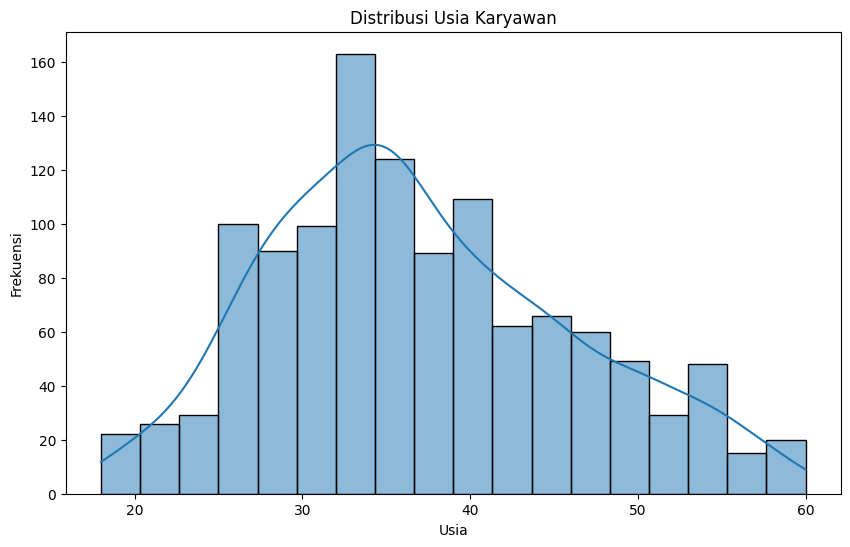

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


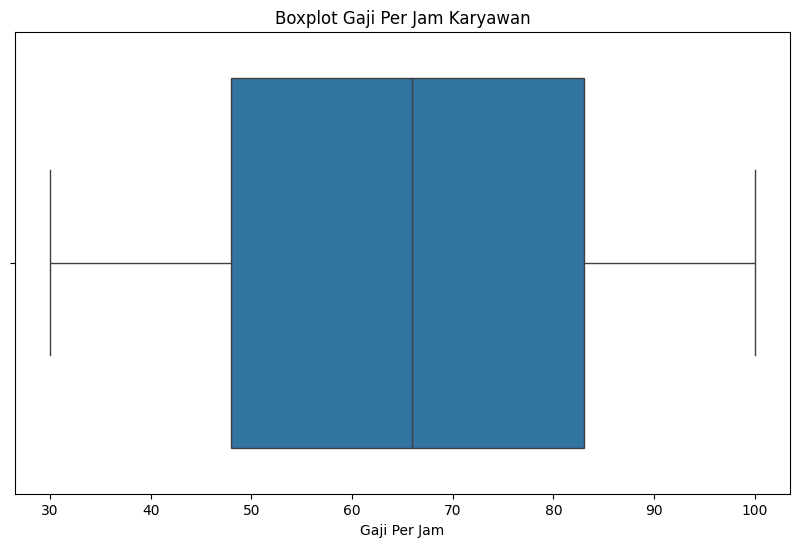

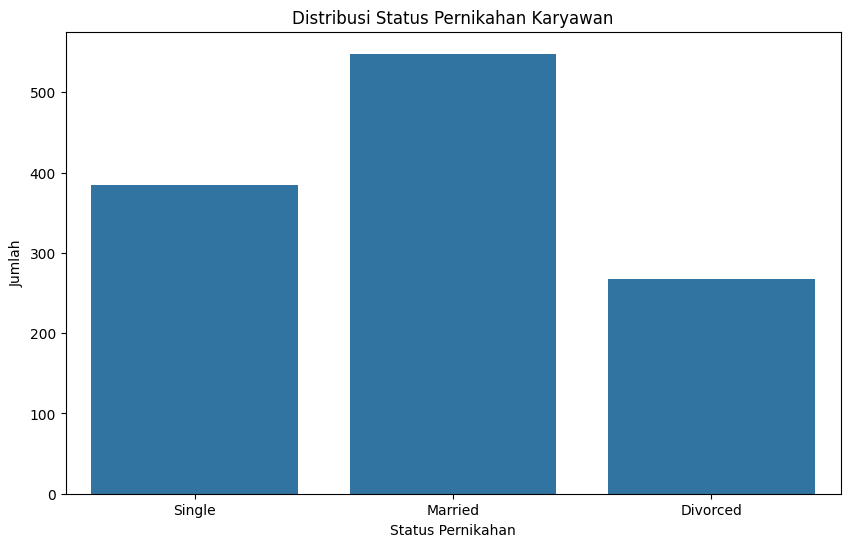

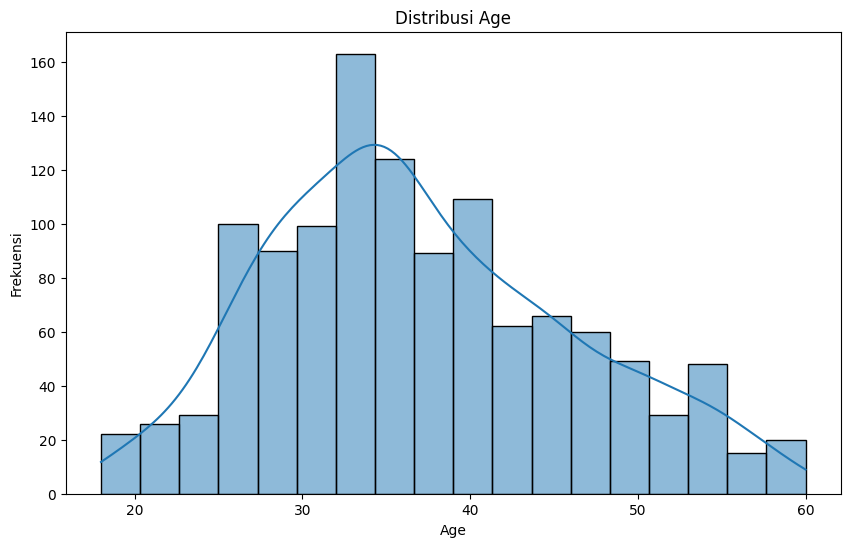

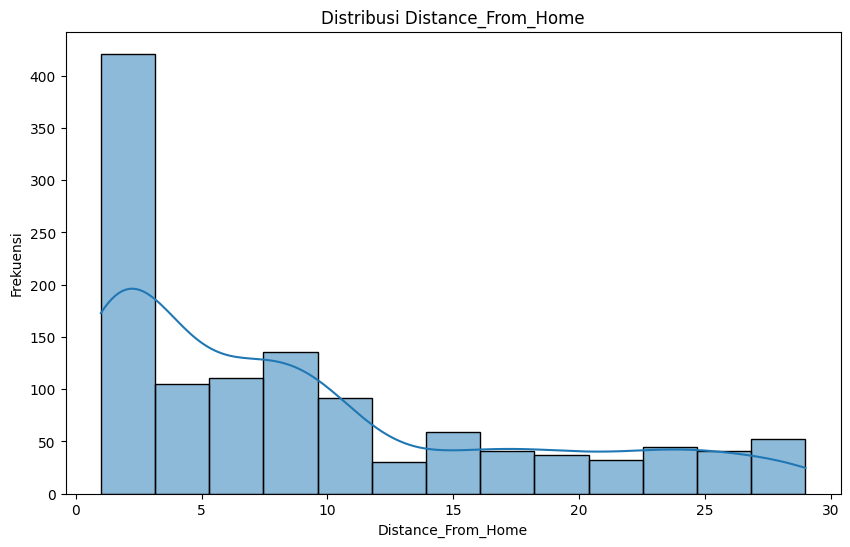

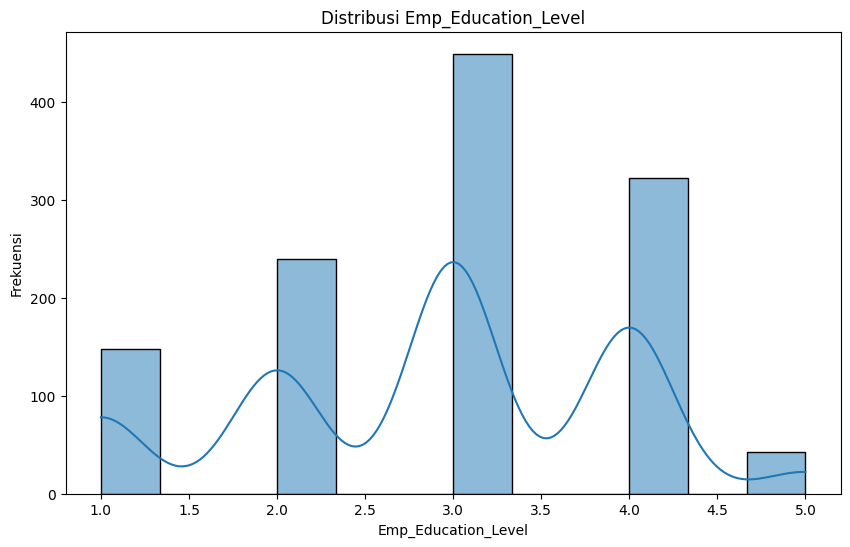

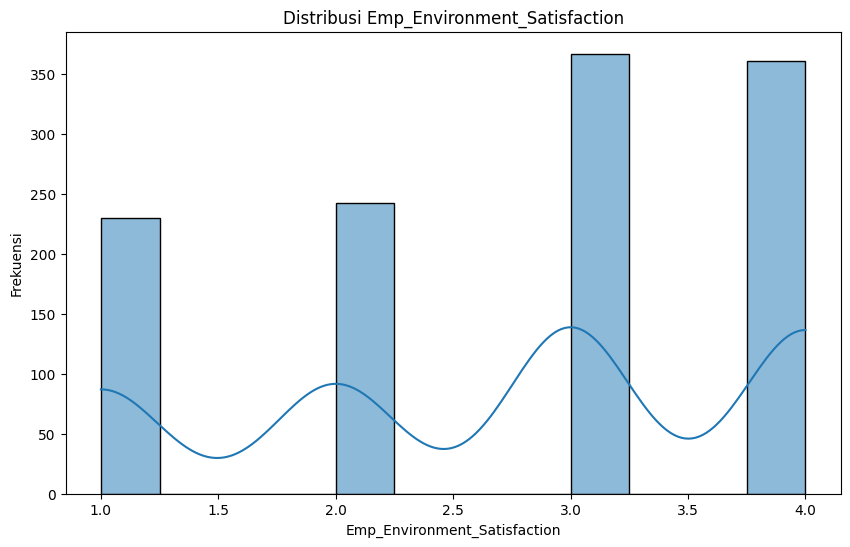

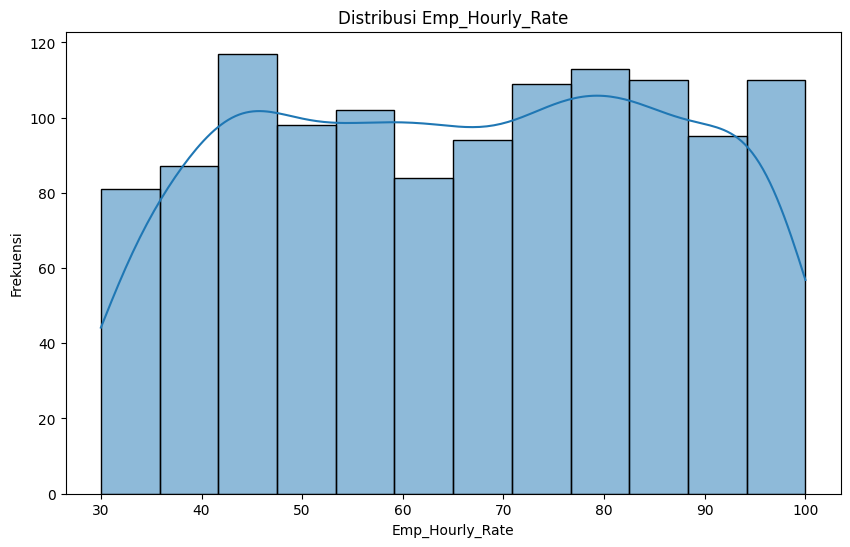

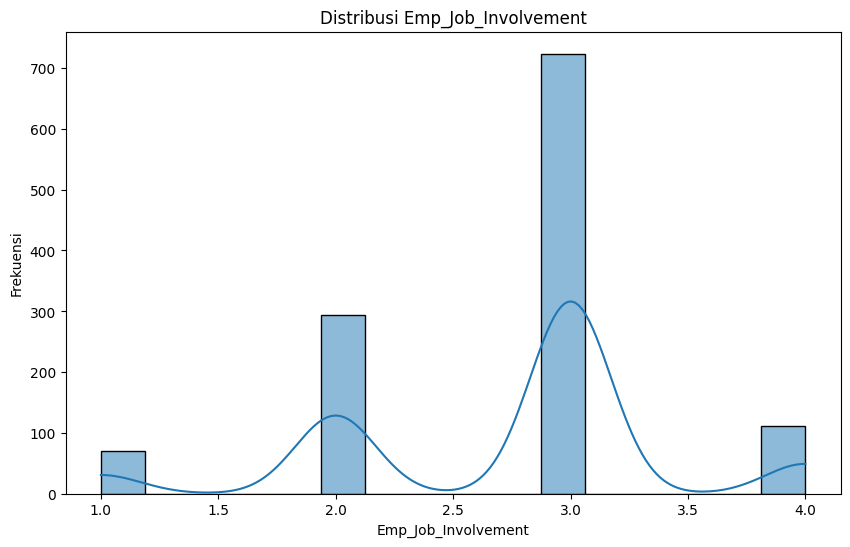

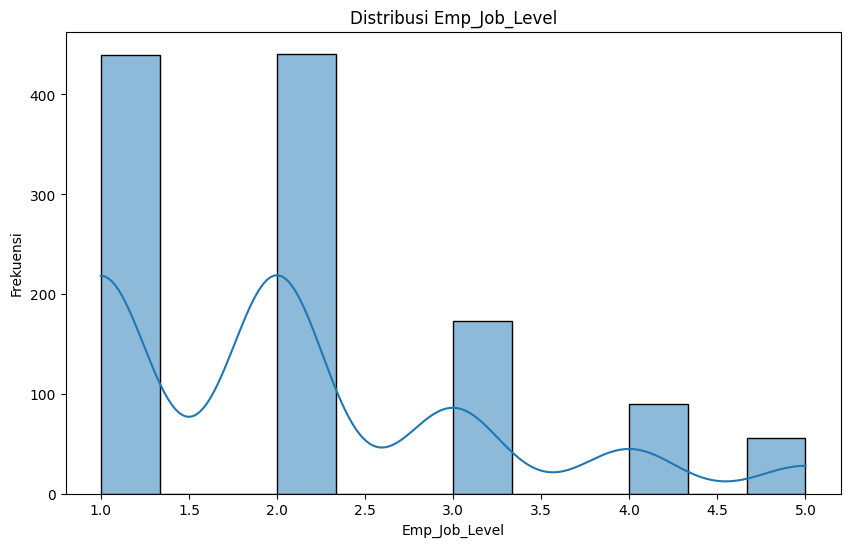

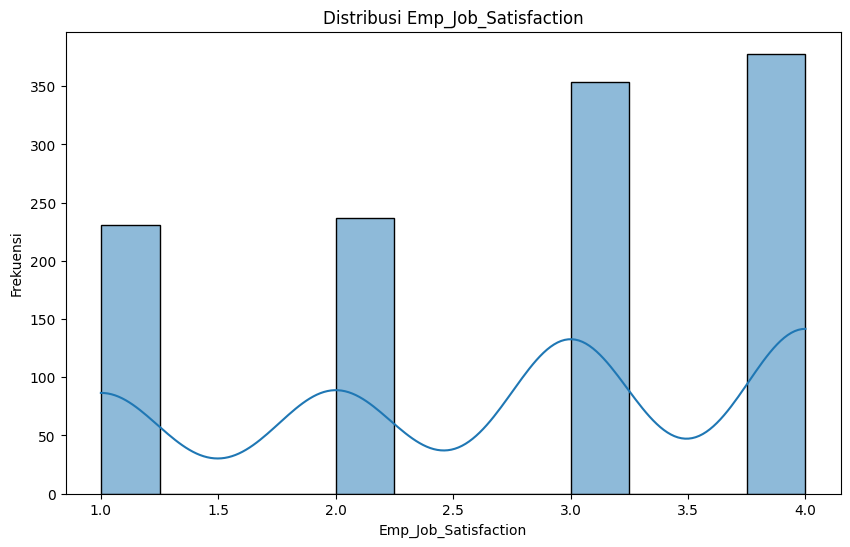

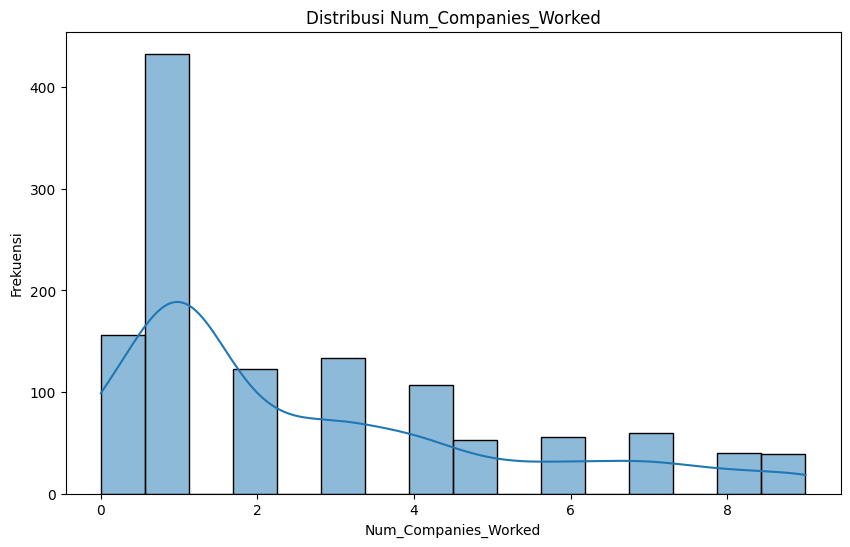

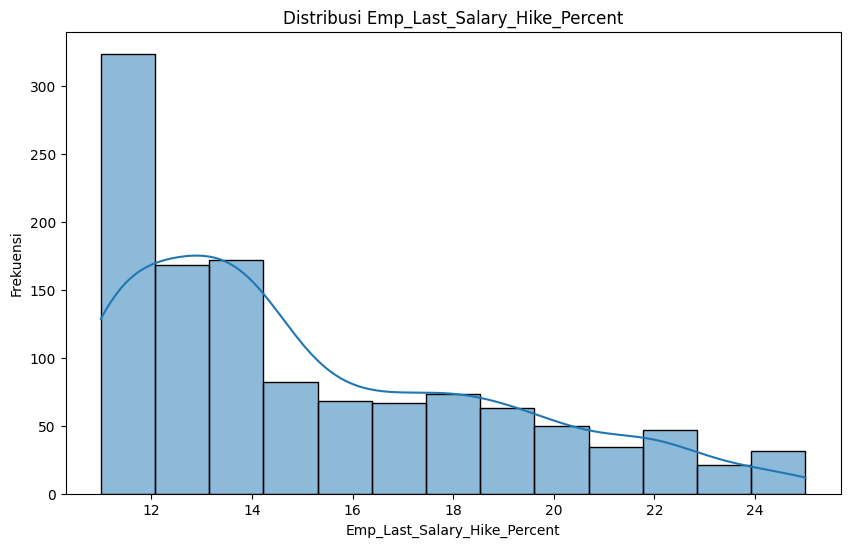

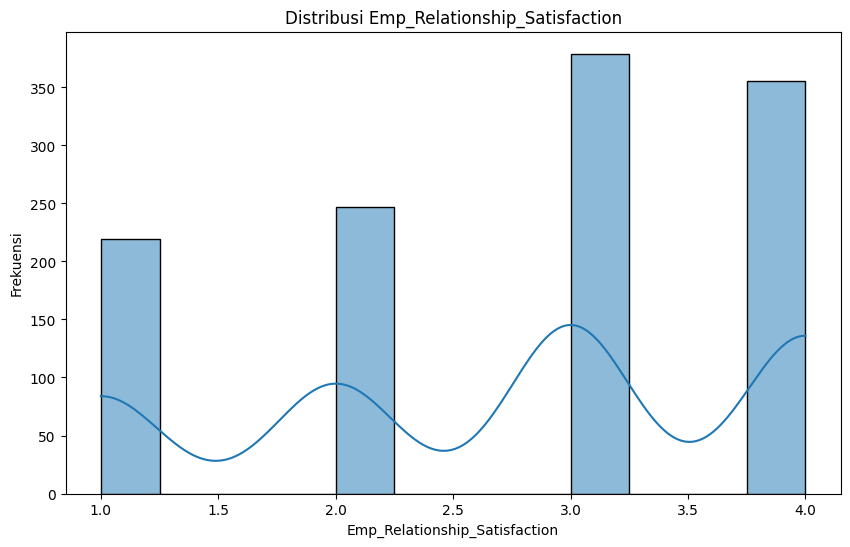

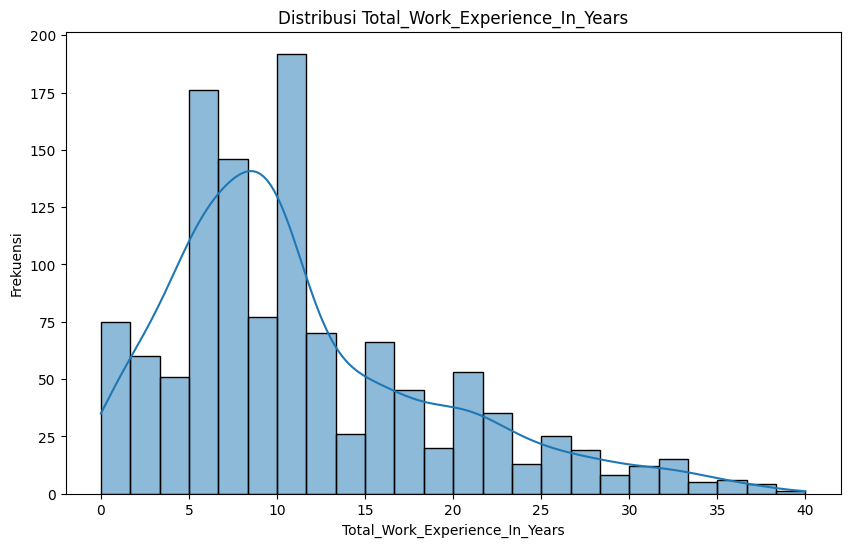

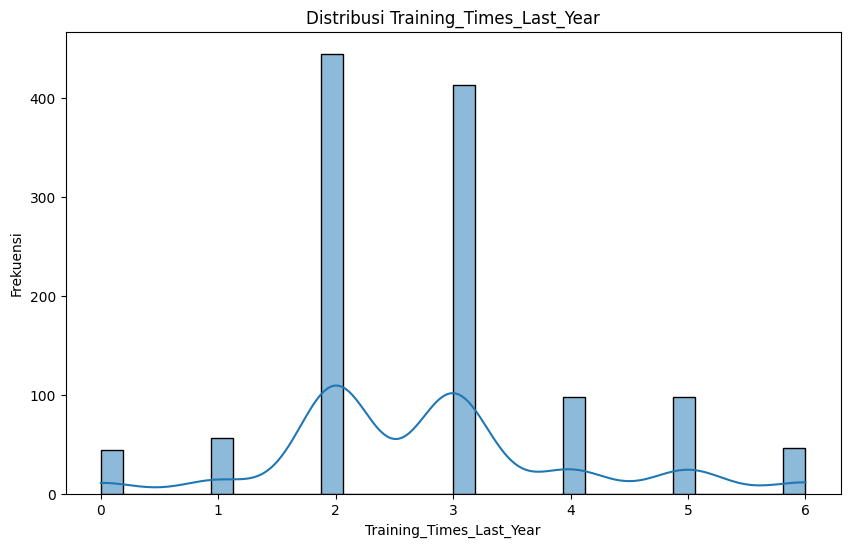

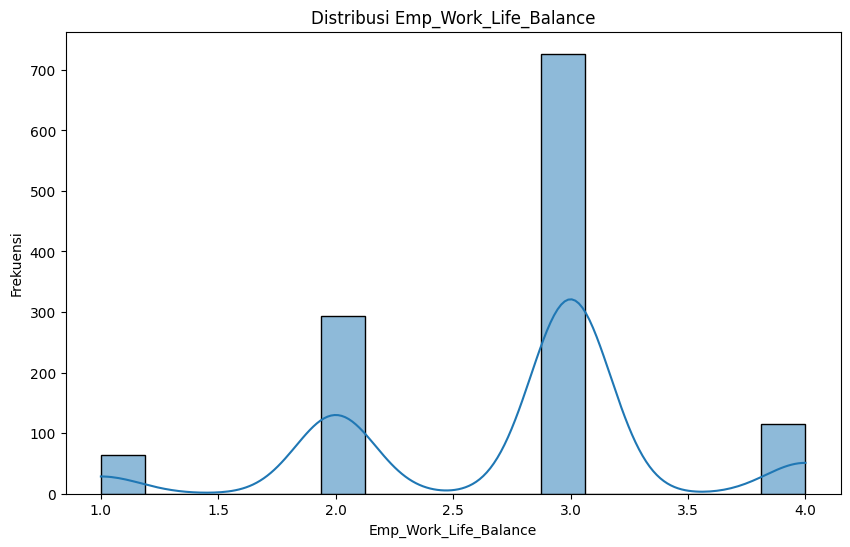

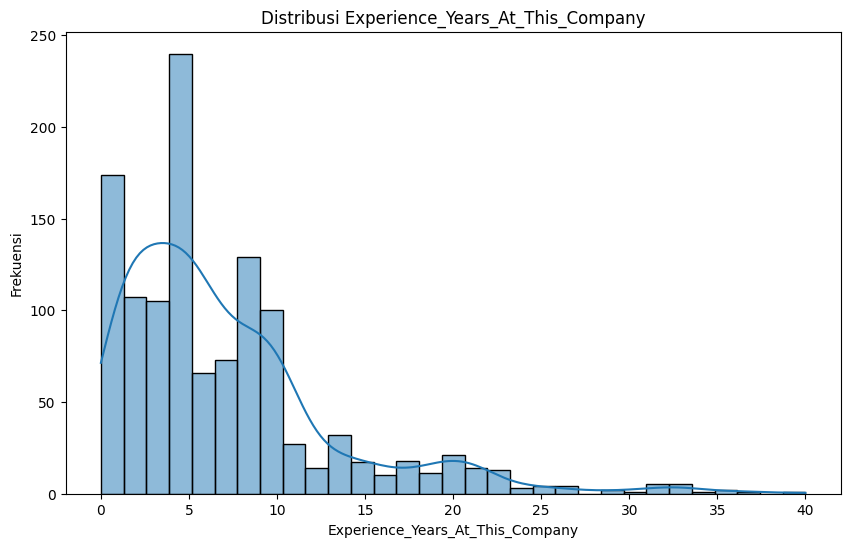

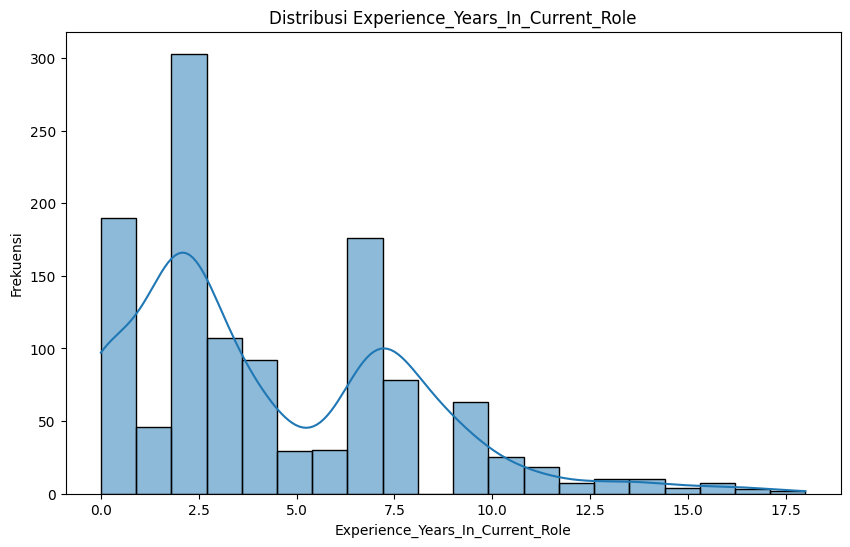

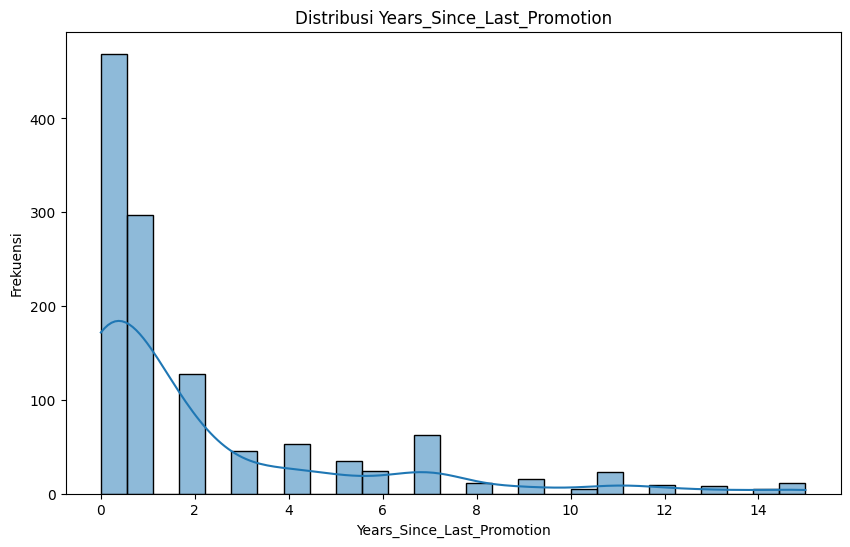

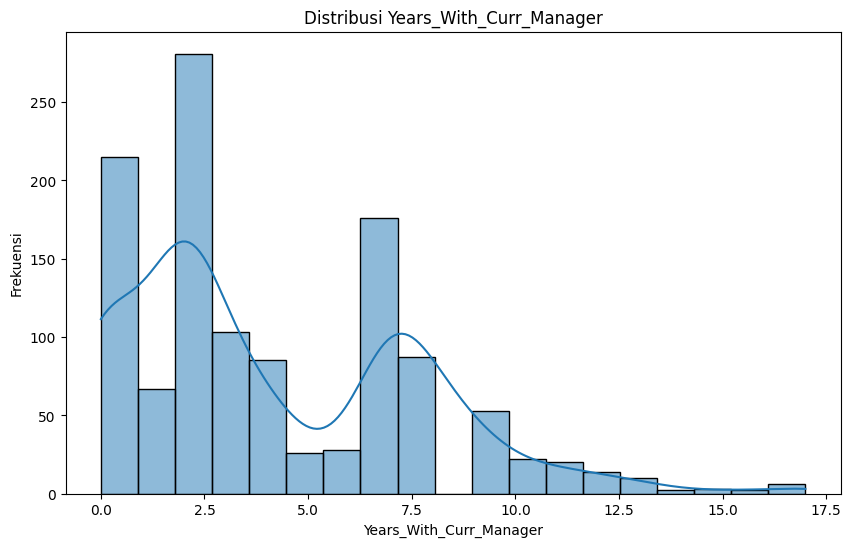

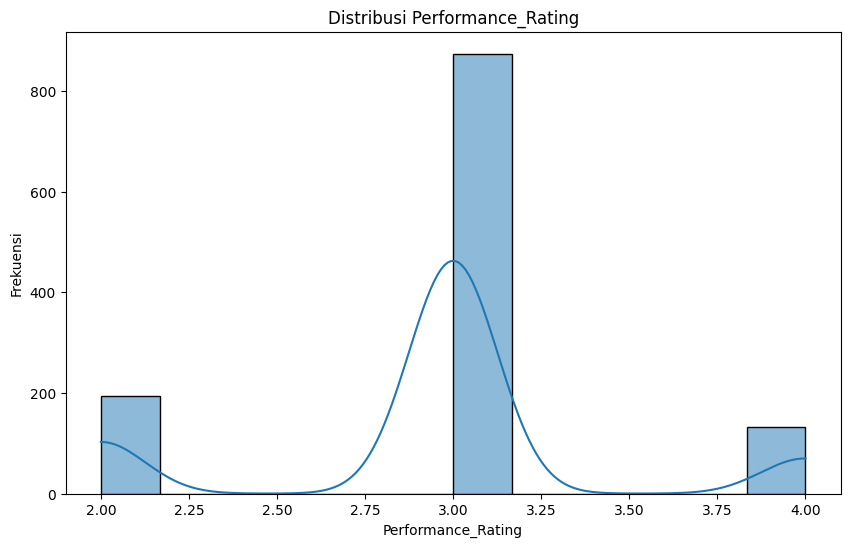

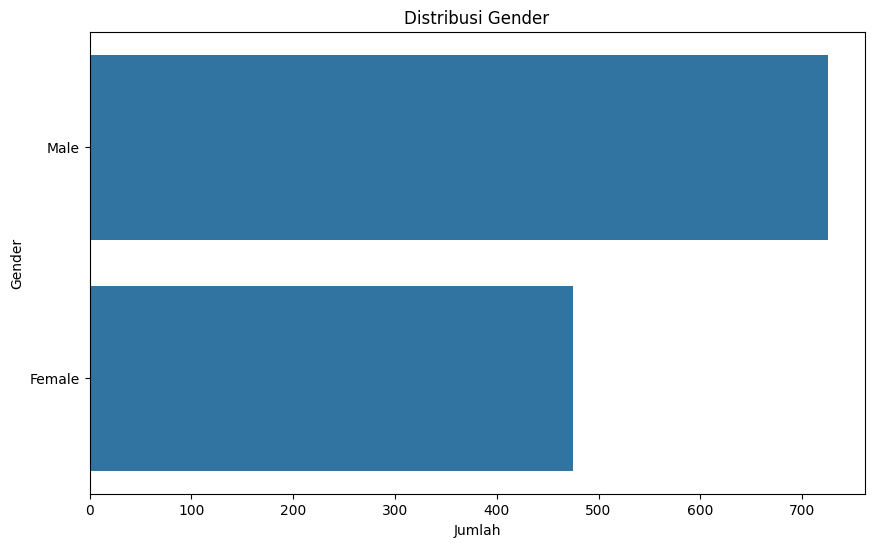

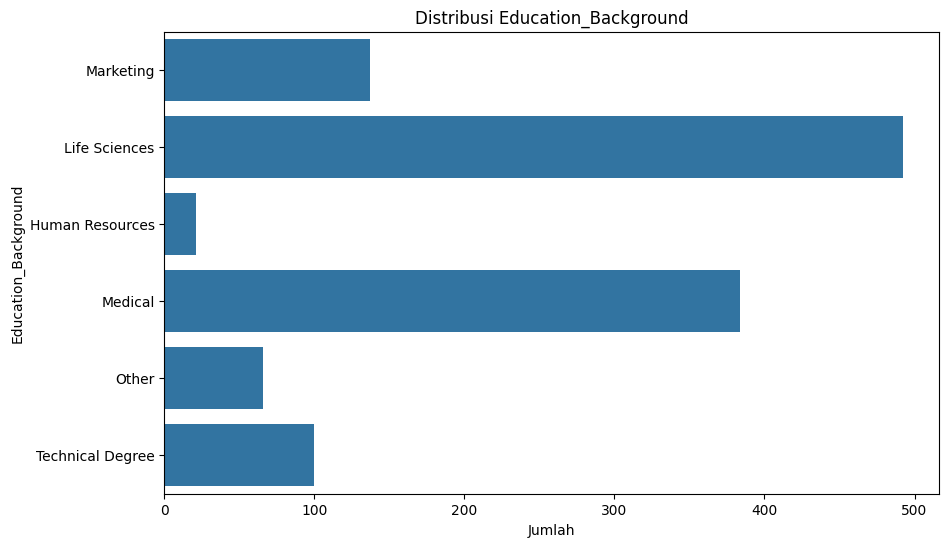

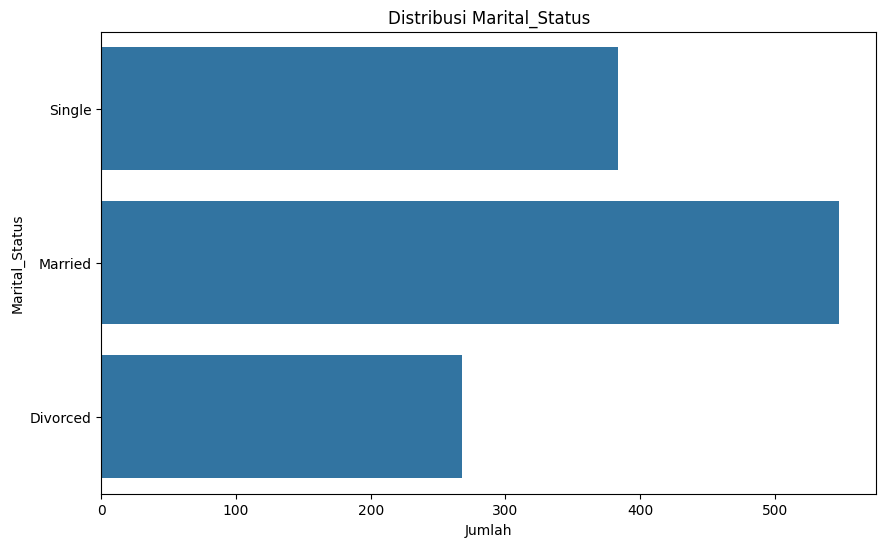

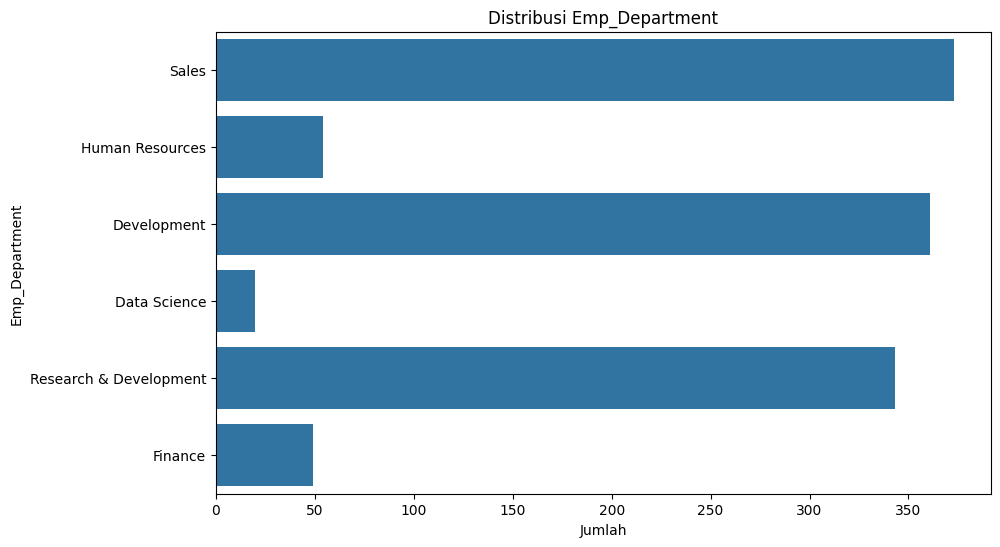

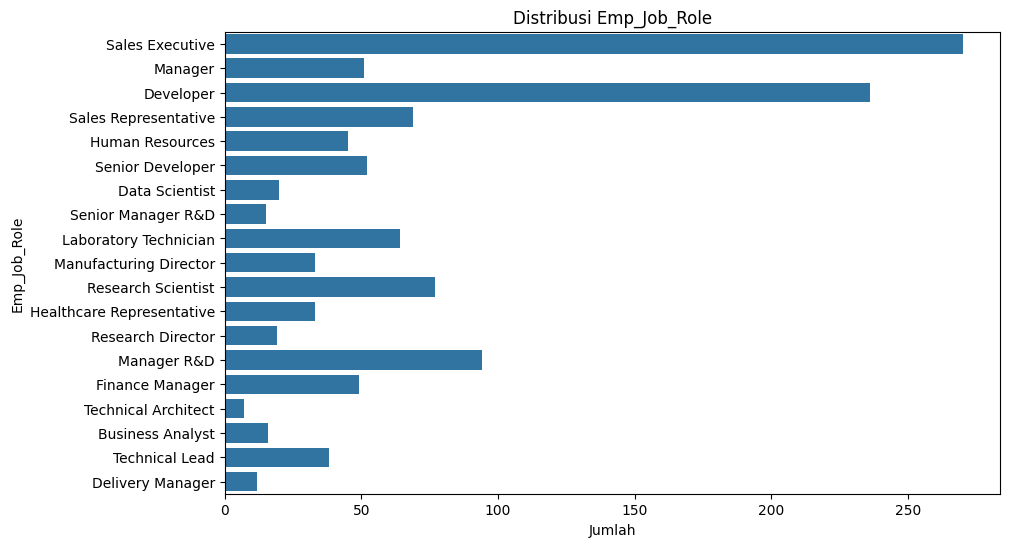

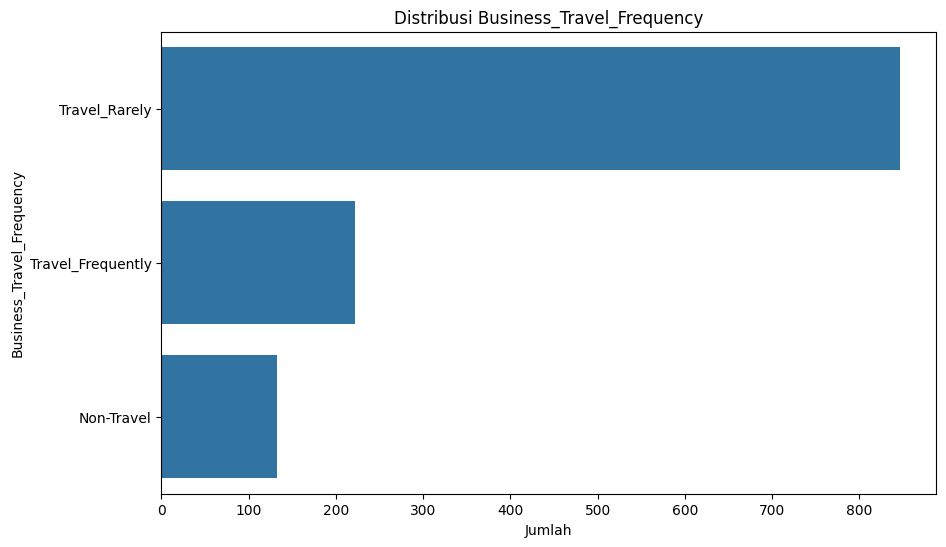

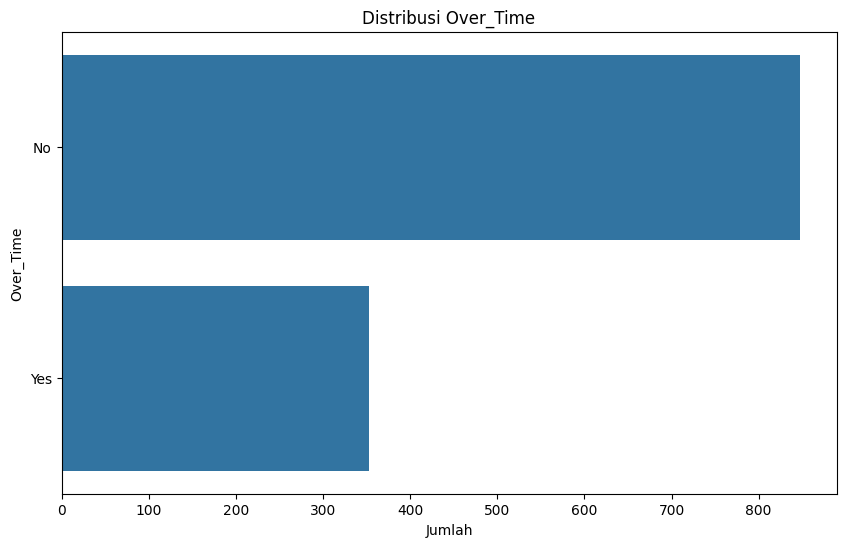

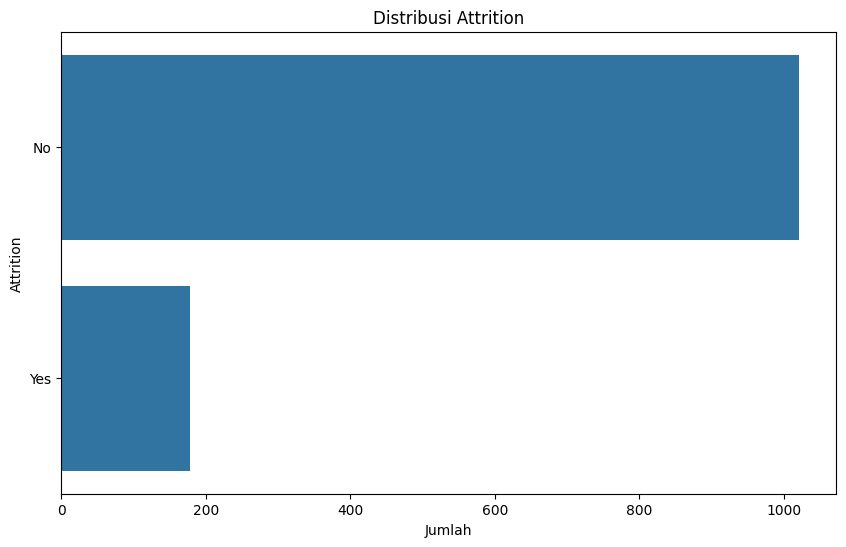

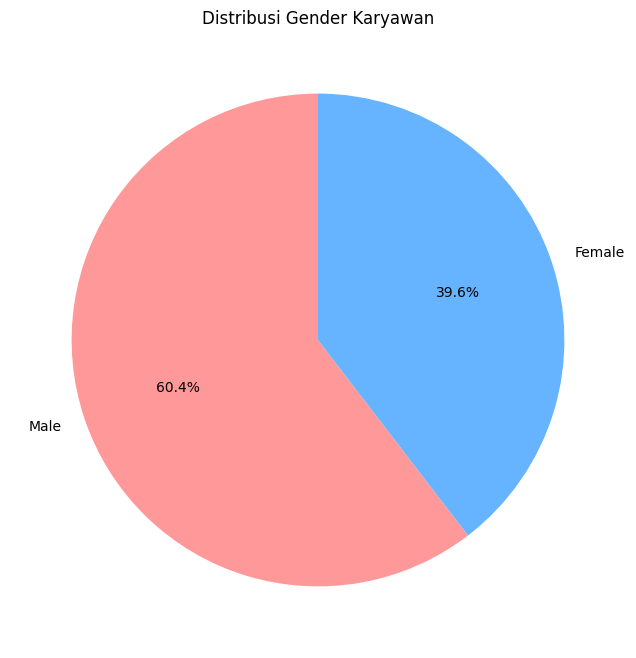

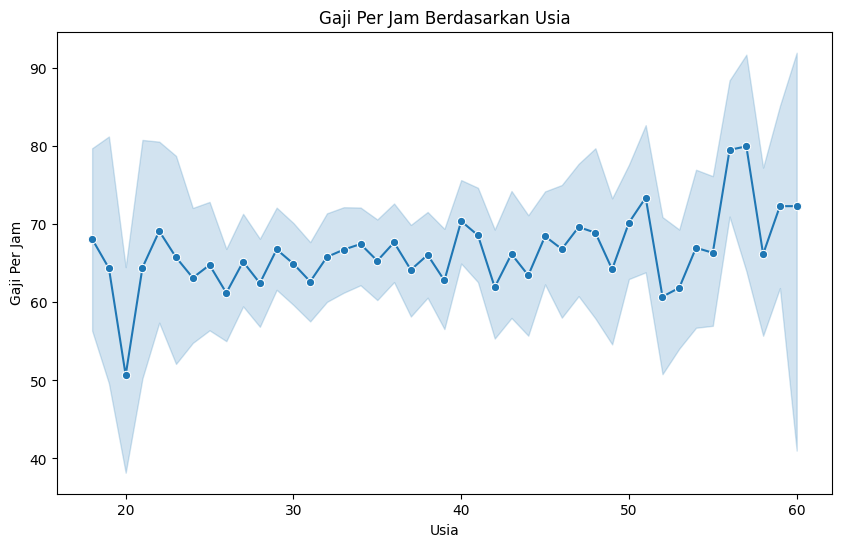

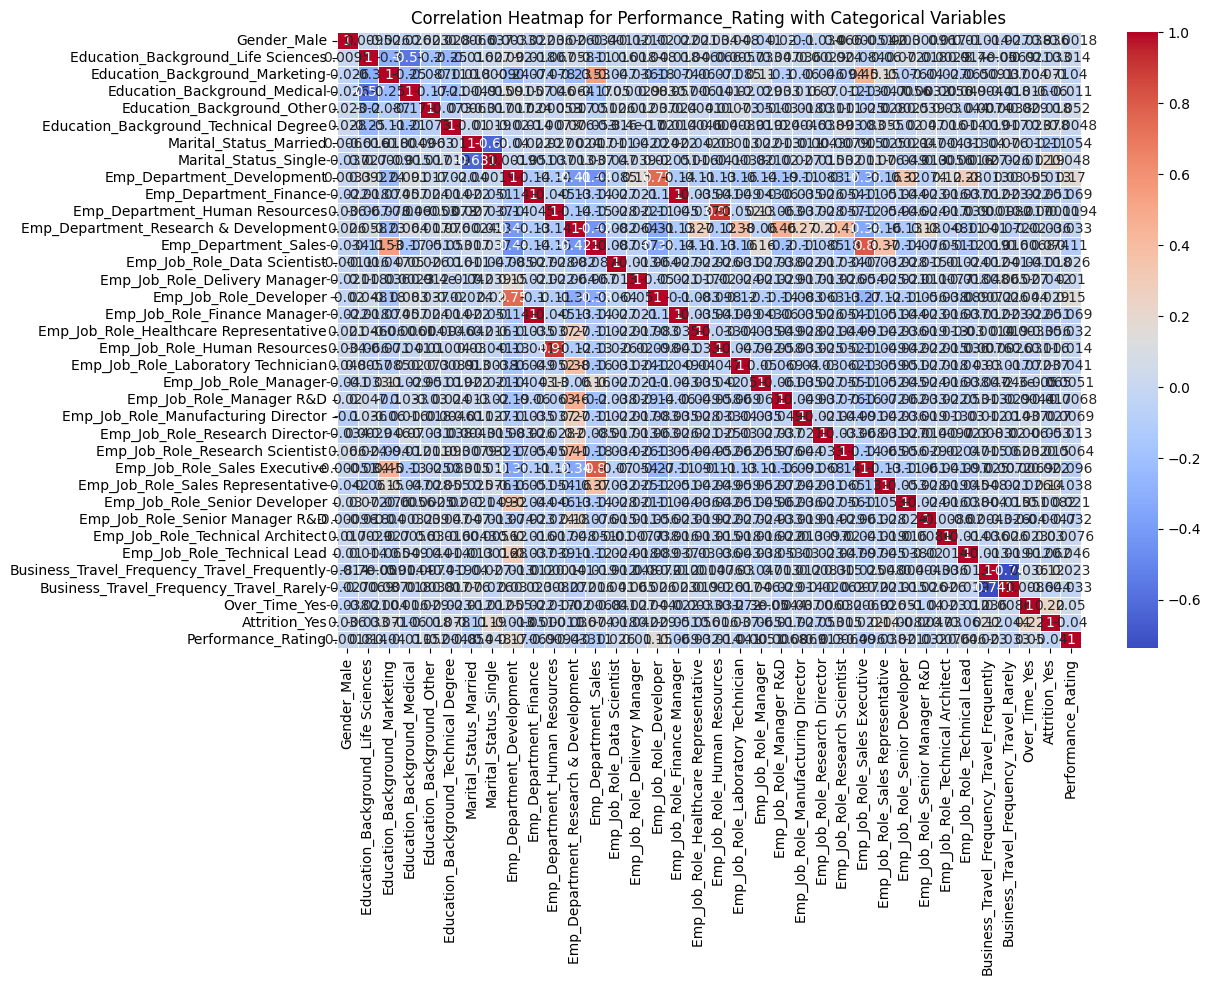

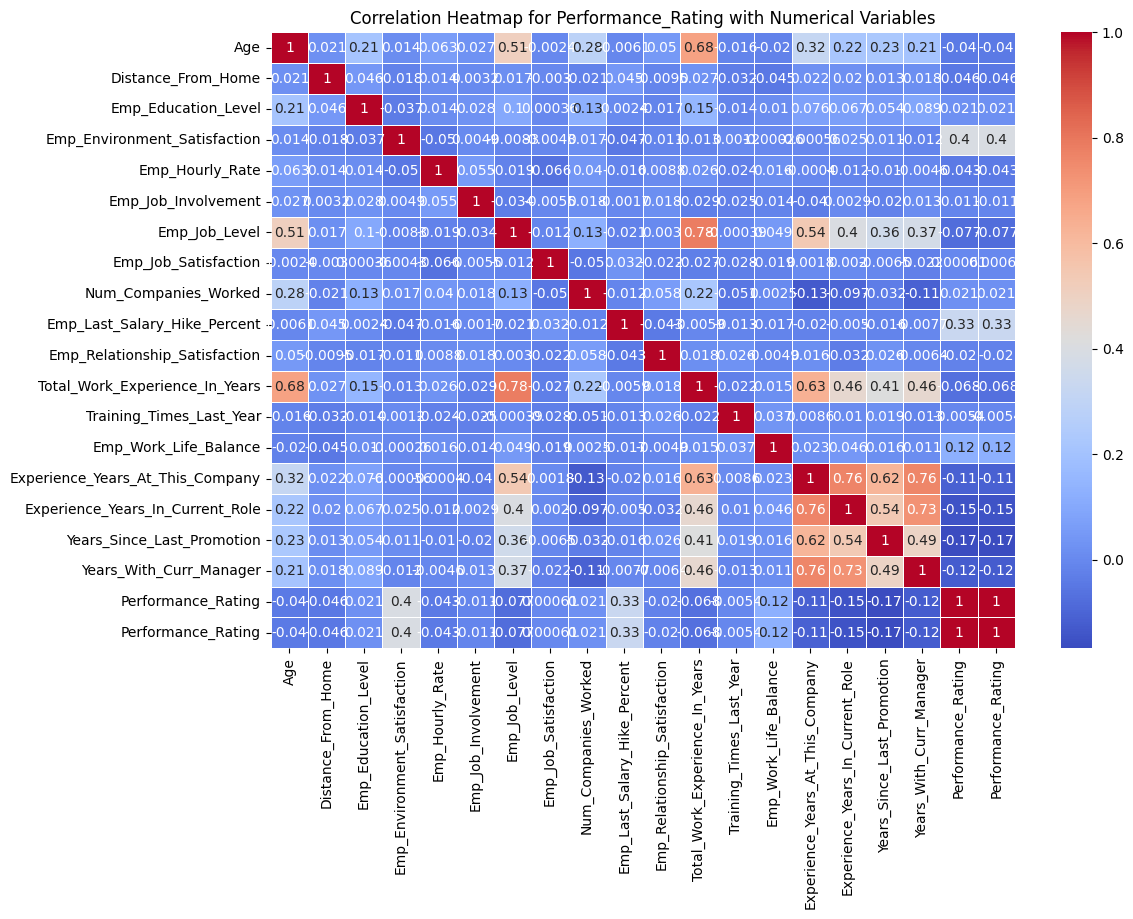

In [ ]:
# Histogram for age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data_cleaned['Age'], kde=True)
plt.title('Distribusi Usia Karyawan')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.show()

# Boxplot for hourly wages
plt.figure(figsize=(10, 6))
sns.boxplot(x='Emp_Hourly_Rate', data=data_cleaned)
plt.title('Boxplot Gaji Per Jam Karyawan')
plt.xlabel('Gaji Per Jam')
plt.show()

# Countplot for marital status
plt.figure(figsize=(10, 6))
sns.countplot(x='Marital_Status', data=data_cleaned)
plt.title('Distribusi Status Pernikahan Karyawan')
plt.xlabel('Status Pernikahan')
plt.ylabel('Jumlah')
plt.show()

# Additional visualizations for numeric variables
numerical_columns = data_cleaned.select_dtypes(include=['int64', 'float64']).columns
for column in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data_cleaned[column], kde=True)
    plt.title(f'Distribusi {column}')
    plt.xlabel(column)
    plt.ylabel('Frekuensi')
    plt.show()

# Additional visualizations for categorical variables
categorical_columns = data_cleaned.select_dtypes(include=['object']).columns
for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=column, data=data_cleaned)
    plt.title(f'Distribusi {column}')
    plt.xlabel('Jumlah')
    plt.ylabel(column)
    plt.show()

# Pie chart for gender distribution
plt.figure(figsize=(8, 8))
data_cleaned['Gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribusi Gender Karyawan')
plt.ylabel('')
plt.show()

# Line chart for hourly wages by age
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age', y='Emp_Hourly_Rate', data=data_cleaned, marker='o')
plt.title('Gaji Per Jam Berdasarkan Usia')
plt.xlabel('Usia')
plt.ylabel('Gaji Per Jam')
plt.show()

# Correlation heatmap for Performance_Rating with categorical variables
categorical_columns_encoded = [col for col in data_encoded.columns if col.startswith(tuple(categorical_columns))]
categorical_columns_encoded.append('Performance_Rating')

plt.figure(figsize=(12, 8))
correlation_matrix_categorical = data_encoded[categorical_columns_encoded].corr()
sns.heatmap(correlation_matrix_categorical, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Performance_Rating with Categorical Variables')
plt.show()

# Correlation heatmap for Performance_Rating with numerical variables
numerical_columns = list(numerical_columns)  # Convert Index to list
numerical_columns.append('Performance_Rating')

plt.figure(figsize=(12, 8))
correlation_matrix_numerical = data_encoded[numerical_columns].corr()
sns.heatmap(correlation_matrix_numerical, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Performance_Rating with Numerical Variables')
plt.show()

**Performance By Department**

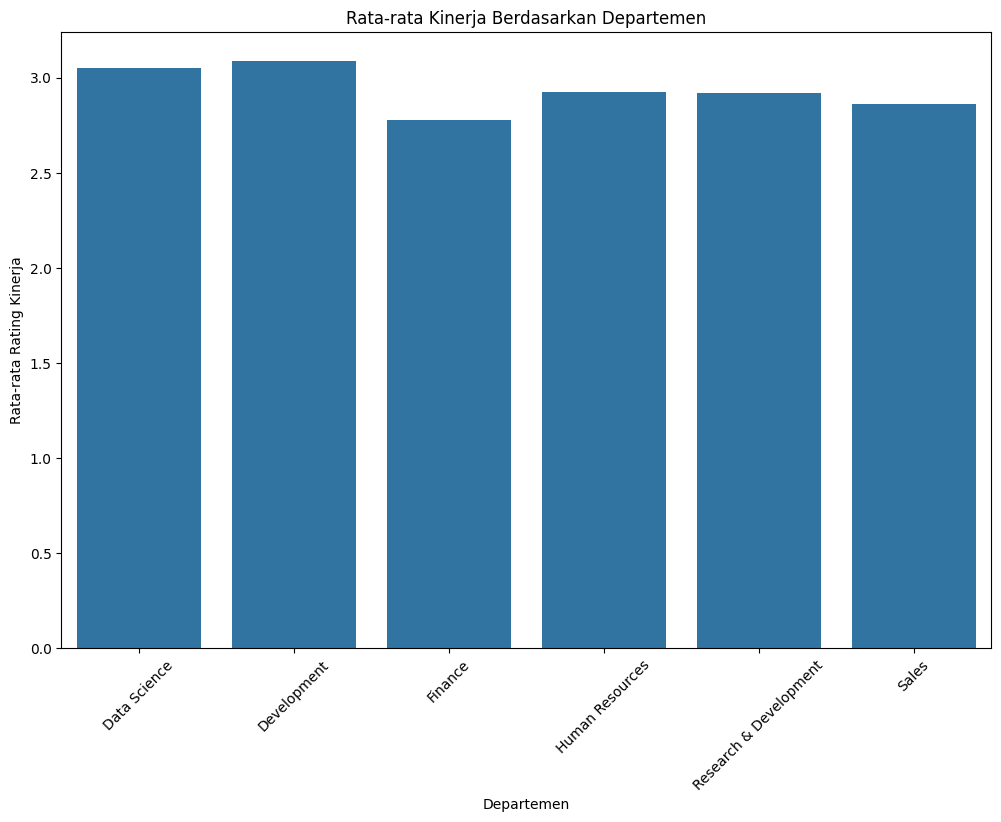

In [ ]:
# Bar plot dapat digunakan untuk menunjukkan rata-rata kinerja di setiap departemen.
plt.figure(figsize=(12, 8))
avg_performance = data_cleaned.groupby('Emp_Department')['Performance_Rating'].mean().reset_index()
sns.barplot(x='Emp_Department', y='Performance_Rating', data=avg_performance)
plt.title('Rata-rata Kinerja Berdasarkan Departemen')
plt.xlabel('Departemen')
plt.ylabel('Rata-rata Rating Kinerja')
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When 

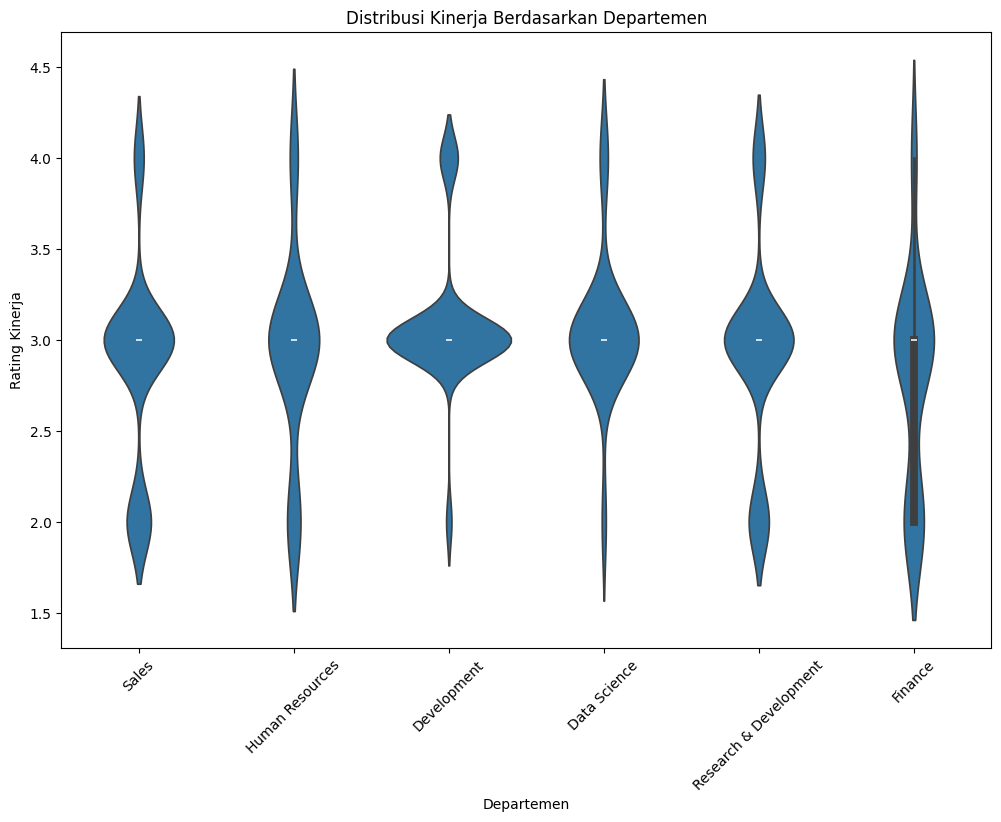

In [ ]:
# Violin plot provides information about data distribution and probability density across departments.
plt.figure(figsize=(12, 8))
sns.violinplot(x='Emp_Department', y='Performance_Rating', data=data_cleaned)
plt.title('Distribusi Kinerja Berdasarkan Departemen')
plt.xlabel('Departemen')
plt.ylabel('Rating Kinerja')
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 84.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 35.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 85.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-

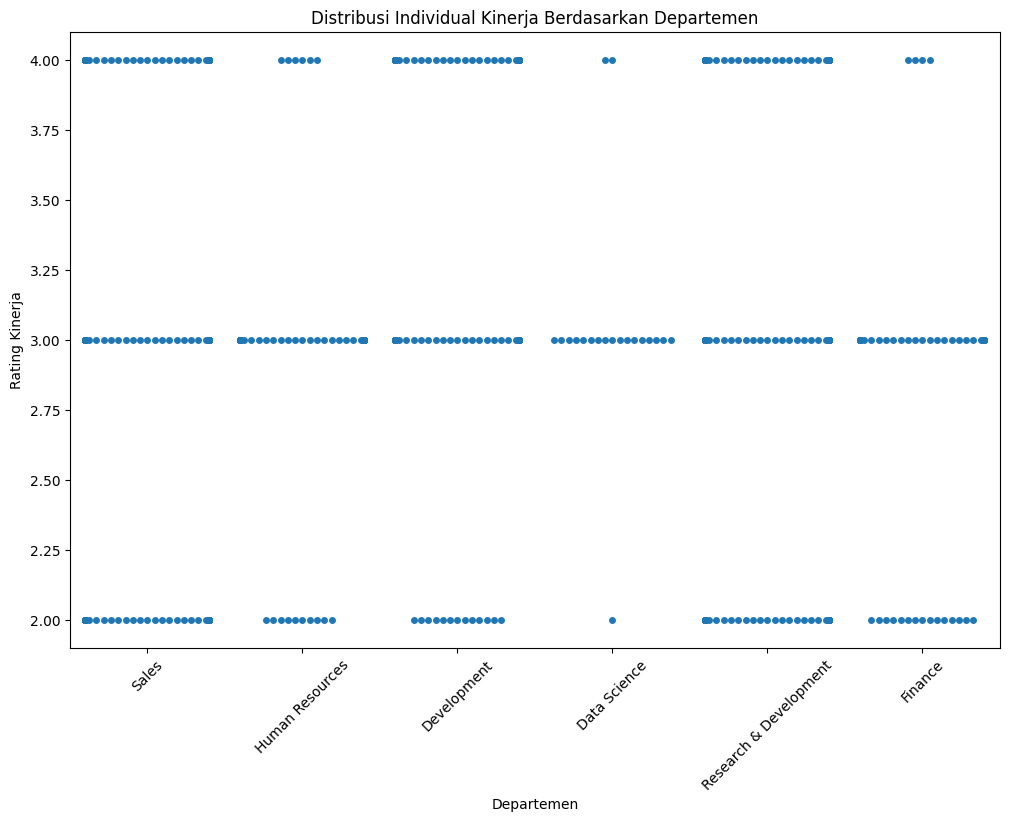

In [ ]:
# Swarm plots can be used to show the individual distribution of data points in each department.
plt.figure(figsize=(12, 8))
sns.swarmplot(x='Emp_Department', y='Performance_Rating', data=data_cleaned)
plt.title('Distribusi Individual Kinerja Berdasarkan Departemen')
plt.xlabel('Departemen')
plt.ylabel('Rating Kinerja')
plt.xticks(rotation=45)
plt.show()

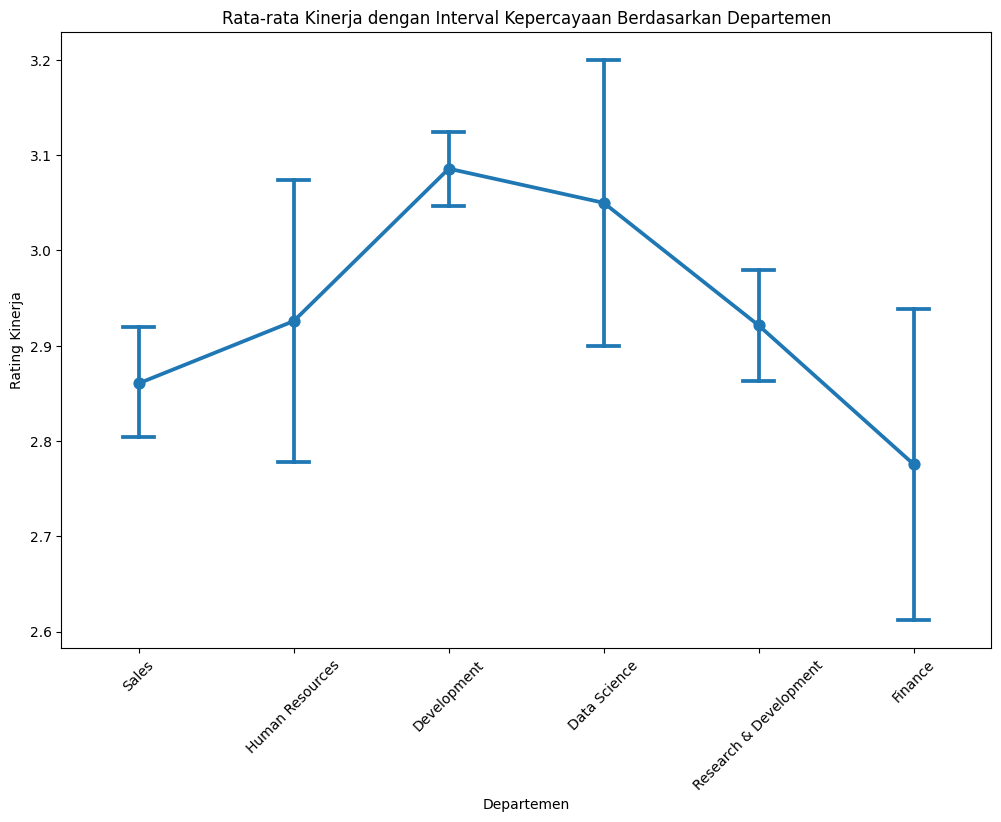

In [ ]:
# Point plots can be used to show the average performance in each department with confidence intervals.
plt.figure(figsize=(12, 8))
sns.pointplot(x='Emp_Department', y='Performance_Rating', data=data_cleaned, capsize=.2)
plt.title('Rata-rata Kinerja dengan Interval Kepercayaan Berdasarkan Departemen')
plt.xlabel('Departemen')
plt.ylabel('Rating Kinerja')
plt.xticks(rotation=45)
plt.show()

**Top 3 Important Factors Effecting Employee Performance**

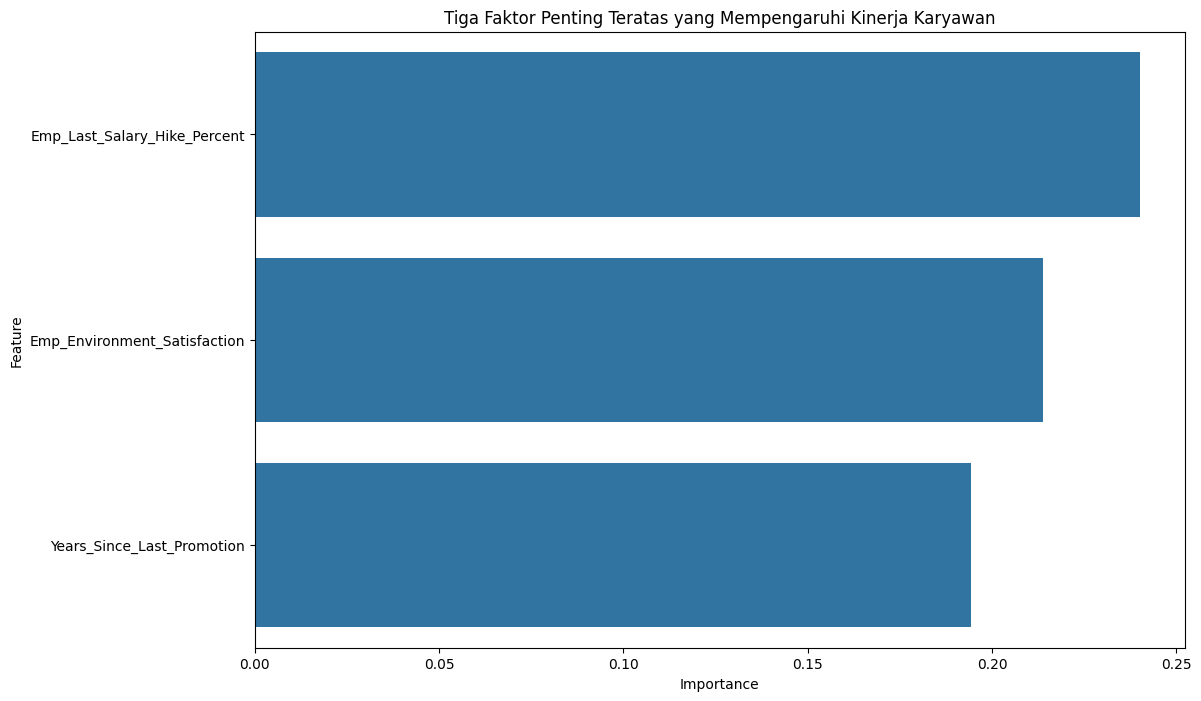


Tiga Faktor Penting Teratas yang Mempengaruhi Kinerja Karyawan:
                         Feature  Importance
9   Emp_Last_Salary_Hike_Percent    0.240290
3   Emp_Environment_Satisfaction    0.213835
16    Years_Since_Last_Promotion    0.194356


In [ ]:
# Converting categorical variables to numeric for further analysis
data_encoded = pd.get_dummies(data_cleaned, drop_first=True)

# Separating features and targets
X = data_encoded.drop(columns=['Performance_Rating'])
y = data_encoded['Performance_Rating']

# Training a RandomForestRegressor model to determine feature importance
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Getting the importance of features
feature_importances = model.feature_importances_

# Creating a DataFrame for visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Visualization of feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(3))
plt.title('Tiga Faktor Penting Teratas yang Mempengaruhi Kinerja Karyawan')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("\nTiga Faktor Penting Teratas yang Mempengaruhi Kinerja Karyawan:")
print(features_df.head(3))

**A trained model which can predict the employee performance based on factors as inputs. This
will be used to hire employees**


Evaluasi Model:
Mean Squared Error: 0.062303333333333336
Root Mean Squared Error: 0.24960635675666062
Mean Absolute Error: 0.10949999999999997
Mean Absolute Percentage Error: 3.8531249999999995%
R-squared: 0.7329062220899077


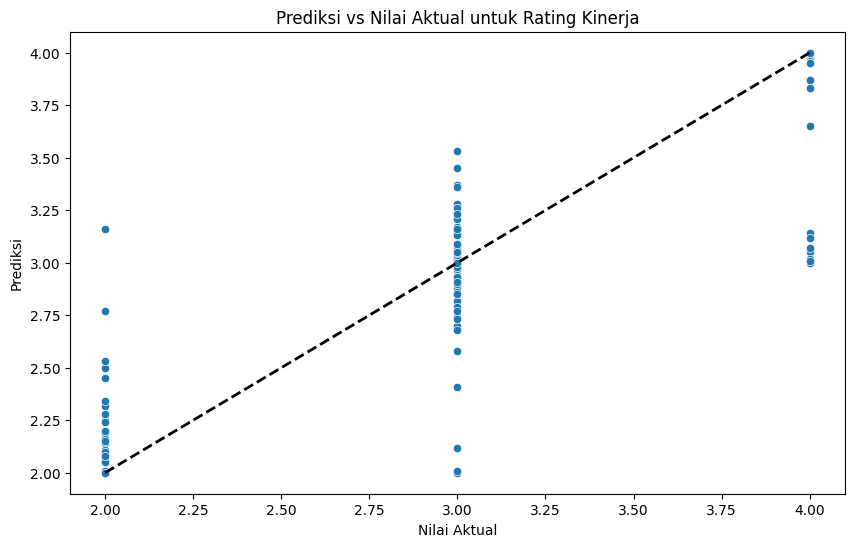

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training a RandomForestRegressor model on the training set
model.fit(X_train, y_train)

# Predicting performance on the test set
y_pred = model.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nEvaluasi Model:")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Absolute Percentage Error: {mape}%")
print(f"R-squared: {r2}")

# Visualization of predicted results vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Prediksi vs Nilai Aktual untuk Rating Kinerja')
plt.xlabel('Nilai Aktual')
plt.ylabel('Prediksi')
plt.show()

**Additional Analysis**

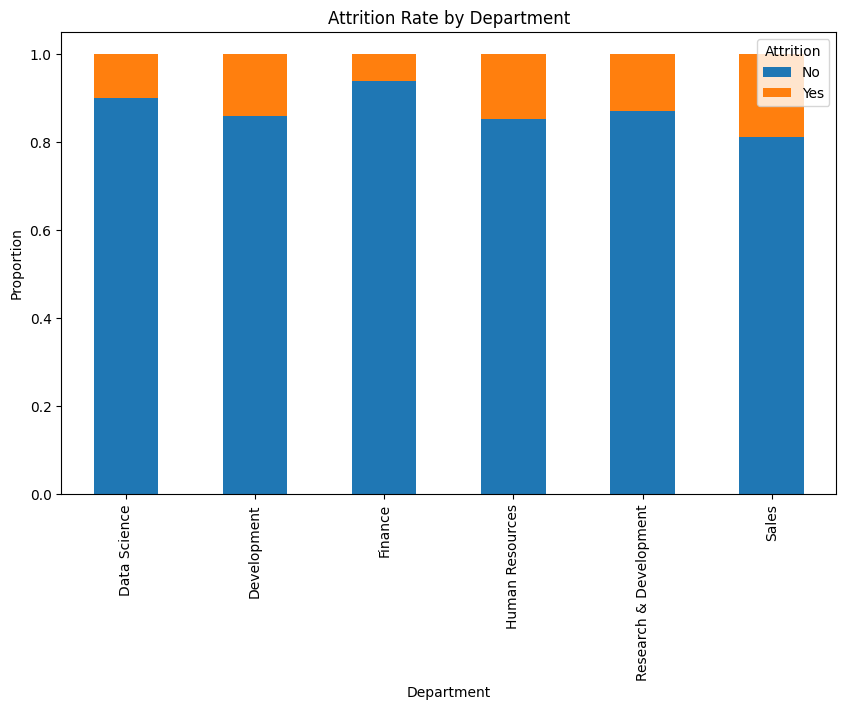

In [ ]:
# Attrition rate by department
attrition_by_department = data_cleaned.groupby('Emp_Department')['Attrition'].value_counts(normalize=True).unstack().fillna(0)
attrition_by_department.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Proportion')
plt.show()

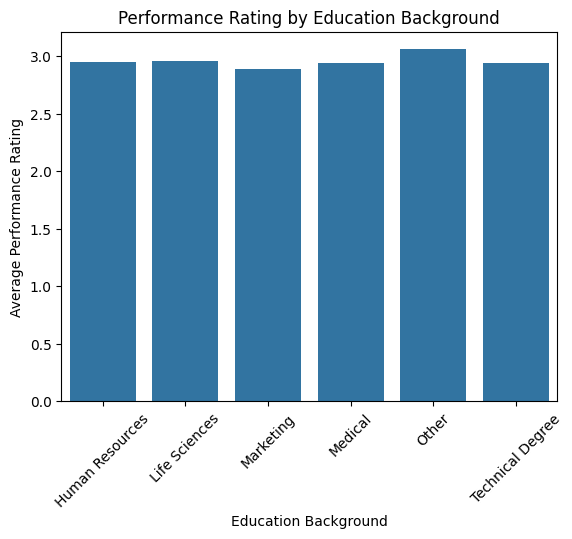

In [ ]:
# Performance by education background
performance_by_education = data_cleaned.groupby('Education_Background')['Performance_Rating'].mean().reset_index()
sns.barplot(x='Education_Background', y='Performance_Rating', data=performance_by_education)
plt.title('Performance Rating by Education Background')
plt.xlabel('Education Background')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=45)
plt.show()

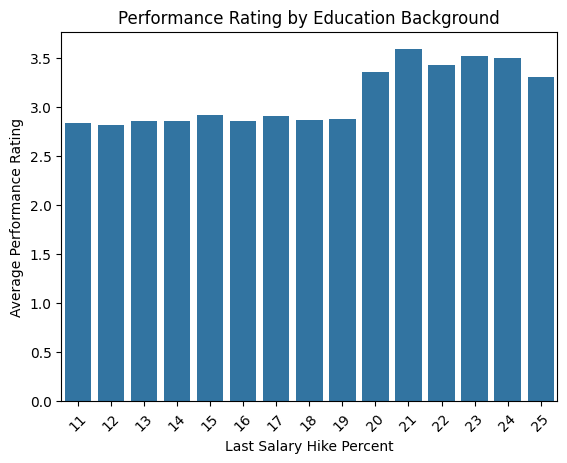

In [ ]:
# Performance by Last Salary Hike Percent
performance_by_LastSalaryHikePercent = data_cleaned.groupby('Emp_Last_Salary_Hike_Percent')['Performance_Rating'].mean().reset_index()
sns.barplot(x='Emp_Last_Salary_Hike_Percent', y='Performance_Rating', data=performance_by_LastSalaryHikePercent)
plt.title('Performance Rating by Last Salary Hike Percent')
plt.xlabel('Last Salary Hike Percent')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=45)
plt.show()

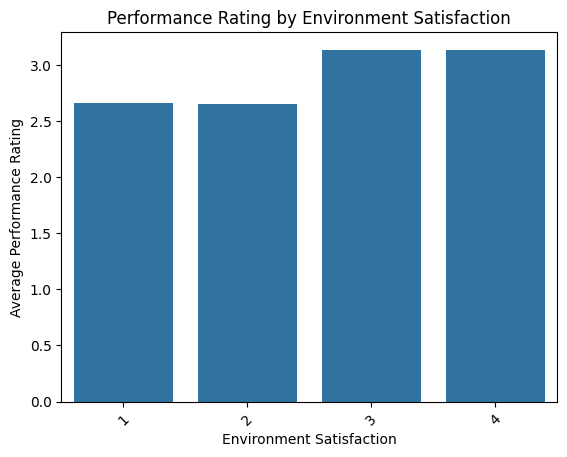

In [ ]:
# Performance by Environment Satisfaction
performance_by_EnvironmentSatisfaction = data_cleaned.groupby('Emp_Environment_Satisfaction')['Performance_Rating'].mean().reset_index()
sns.barplot(x='Emp_Environment_Satisfaction', y='Performance_Rating', data=performance_by_EnvironmentSatisfaction)
plt.title('Performance Rating by Environment Satisfaction')
plt.xlabel('Environment Satisfaction')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=45)
plt.show()

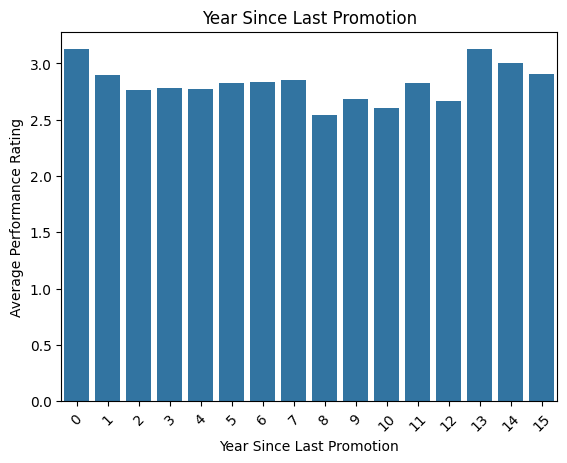

In [ ]:
# Performance by Year Since Last Promotion
performance_by_YearSinceLastPromotion = data_cleaned.groupby('Years_Since_Last_Promotion')['Performance_Rating'].mean().reset_index()
sns.barplot(x='Years_Since_Last_Promotion', y='Performance_Rating', data=performance_by_YearSinceLastPromotion)
plt.title('Year Since Last Promotion')
plt.xlabel('Year Since Last Promotion')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


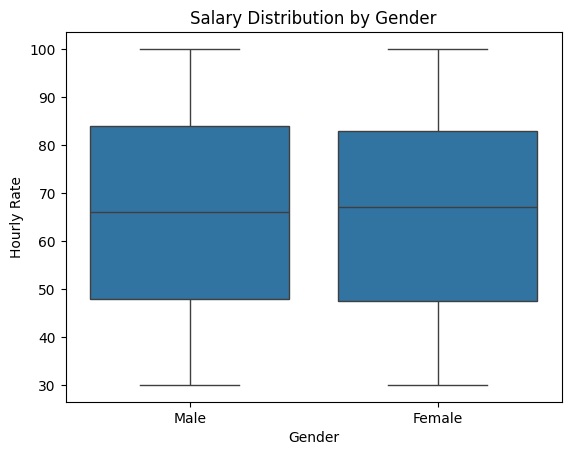

In [ ]:
# Salary distribution by gender
sns.boxplot(x='Gender', y='Emp_Hourly_Rate', data=data_cleaned)
plt.title('Salary Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Hourly Rate')
plt.show()

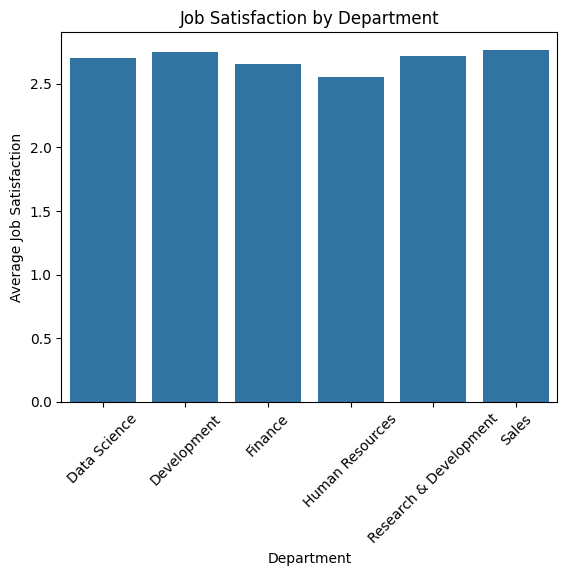

In [ ]:
# Job satisfaction by department
satisfaction_by_department = data_cleaned.groupby('Emp_Department')['Emp_Job_Satisfaction'].mean().reset_index()
sns.barplot(x='Emp_Department', y='Emp_Job_Satisfaction', data=satisfaction_by_department)
plt.title('Job Satisfaction by Department')
plt.xlabel('Department')
plt.ylabel('Average Job Satisfaction')
plt.xticks(rotation=45)
plt.show()

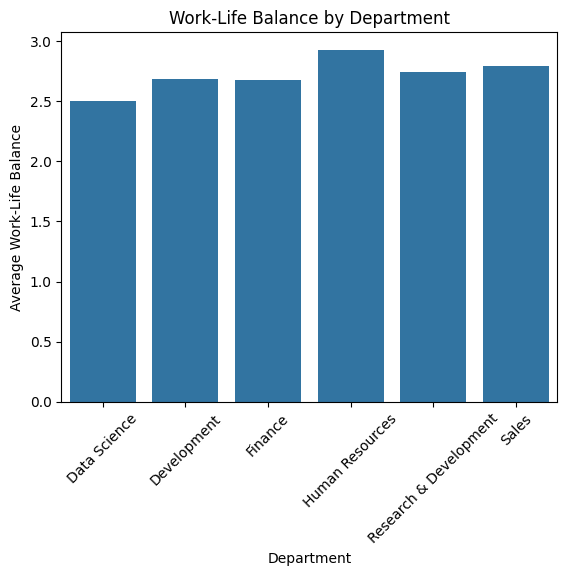

In [ ]:
# Work-life balance by department
balance_by_department = data_cleaned.groupby('Emp_Department')['Emp_Work_Life_Balance'].mean().reset_index()
sns.barplot(x='Emp_Department', y='Emp_Work_Life_Balance', data=balance_by_department)
plt.title('Work-Life Balance by Department')
plt.xlabel('Department')
plt.ylabel('Average Work-Life Balance')
plt.xticks(rotation=45)
plt.show()

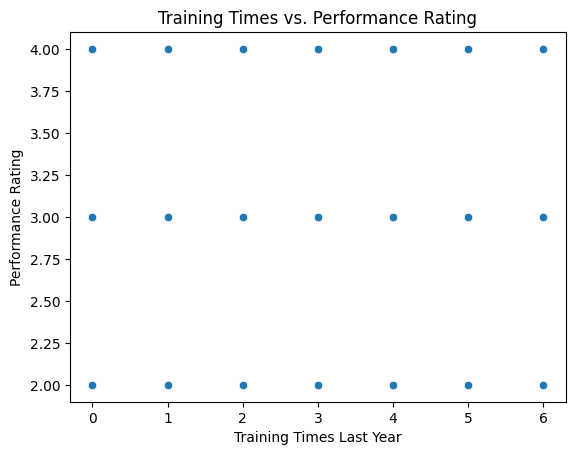

In [ ]:
# Training times vs. performance
sns.scatterplot(x='Training_Times_Last_Year', y='Performance_Rating', data=data_cleaned)
plt.title('Training Times vs. Performance Rating')
plt.xlabel('Training Times Last Year')
plt.ylabel('Performance Rating')
plt.show()

**RESULTS, ANALYSIS AND INSIGHTS**

1. Interesting Relationships in the Data
One interesting relationship that emerged from the data, which wasn’t explicitly covered in the previous sections, is the impact of business travel frequency on performance ratings. Employees who travel frequently for business tend to have varied performance ratings, which could be influenced by factors such as travel stress, time management, and work-life balance. This relationship suggests that managing travel schedules and providing support for frequent travelers could be crucial for maintaining high performance.
2. Most Important Technique Used
The most important technique used in this project was feature importance analysis using Random Forest Regressor. This technique helped identify the key factors influencing employee performance by evaluating the contribution of each feature to the model’s predictions. By understanding which features are most important, we can focus on improving those areas to enhance overall performance.
3. Answers to Business Problems Based on Analysis
•	Employee Attrition:
o	Problem: High attrition rates in certain departments.
o	Answer: Departments like Sales and Development have higher attrition rates. Implementing targeted retention strategies, such as improving job satisfaction and work-life balance, can help reduce attrition.
•	Performance Improvement:
o	Problem: Identifying factors that influence employee performance.
o	Answer: Key factors include job involvement, job satisfaction, and environment satisfaction. Focusing on these areas can lead to better performance outcomes.
•	Salary and Compensation:
o	Problem: Ensuring fair compensation practices.
o	Answer: Analysis shows no significant gender pay gap, but continuous monitoring is essential. Additionally, aligning salary increases with performance ratings can motivate employees.
•	Training and Development:
o	Problem: Evaluating the effectiveness of training programs.
o	Answer: There is a positive correlation between training times and performance ratings. Investing in training programs can enhance employee skills and performance.
4. Additional Business
•	Work-Life Balance: Employees reporting better work-life balance tend to have higher performance ratings. This highlights the importance of policies that support work-life balance, such as flexible working hours and remote work options.
•	Job Satisfaction by Department: Departments like Human Resources and Development report higher job satisfaction, while Sales has lower satisfaction. Addressing specific issues in departments with lower satisfaction can improve overall morale and productivity.
•	Impact of Over Time: Employees working overtime do not necessarily have higher performance ratings. This suggests that excessive overtime may lead to burnout and reduced productivity, emphasizing the need for balanced workloads.
•	Education Background: Employees with backgrounds in Life Sciences and Medical fields tend to have higher performance ratings. This insight can inform hiring strategies to focus on candidates with relevant educational backgrounds.


**Recommendations to improve the employee performance based on insights from analysis:**

1. **Emp_Last_Salary_Hike_Percent (Last Salary Increase Percentage)**
* Fair Salary Increase Policy: Ensure a fair and transparent salary increase policy. Employees who feel financially rewarded tend to be more motivated and productive.
* Performance-Based Salary Increase: Implement a performance-based salary increase system to encourage employees to achieve their targets.
* Clear Communication: Clearly communicate salary increase criteria and process to employees to avoid dissatisfaction and confusion.

2. **Emp_Environment_Satisfaction (Work Environment Satisfaction)**
* Improved Work Facilities: Improve work facilities such as comfortable workspaces, adequate equipment, and a clean and safe environment.
* Positive Work Culture: Create a positive and inclusive work culture where employees feel valued and supported.
* Wellness Programs: Implement wellness programs that include physical and mental health, such as fitness classes, counseling, and recreational activities.

3. **Years_Since_Last_Promotion (Years Since Last Promotion)**
* Clear Promotion Opportunities: Provide clear and fair promotion opportunities to high-performing employees. Employees who see a clear career path tend to be more motivated.
* Career Development Programs: Create career development programs that help employees improve their skills and prepare for promotions.
* Regular Evaluations: Conduct regular performance evaluations to identify employees who are eligible for promotions and provide constructive feedback.

**Additional Recommendation**


* Rewards and Recognition: Reward and recognize high-performing employees to motivate them and other employees.
* Work Flexibility: Consider providing work flexibility such as work-from-home options or flexible work hours to improve employee work-life balance.
* Productivity Tools: Use tools and technology that can help improve employee productivity, such as project management software and collaboration tools.

By implementing these recommendations, employee performance is expected to improve overall.